# 03 - BERT Classification (multi-class + binary)

## 1. Imports and setup

In [1]:
import random
from math import ceil
from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "promise_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

df = pd.read_csv(DATA_PATH)
print(f"Data: {len(df)} requirements, {df['class'].nunique()} classes")

def save_fig(name):
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=300, bbox_inches='tight')

Device: mps
Data: 3677 requirements, 12 classes


## 2. Train/test/val split

In [2]:
X = df["text"].values
y = df["class"].values
groups = df["project_id"].values

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))

X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
y_train, y_val = y_trainval[train_idx], y_trainval[val_idx]

n_train_projects = pd.Series(groups_trainval[train_idx]).nunique()
n_val_projects = pd.Series(groups_trainval[val_idx]).nunique()
n_test_projects = pd.Series(groups[test_idx]).nunique()

print(f"Train: {len(X_train)} reqs from {n_train_projects} projects")
print(f"Val:   {len(X_val)} reqs from {n_val_projects} projects")
print(f"Test:  {len(X_test)} reqs from {n_test_projects} projects")

Train: 2263 reqs from 59 projects
Val:   331 reqs from 11 projects
Test:  1083 reqs from 18 projects


## 3. Tokenizer and dataset wrapper

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class TextClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)
class_labels = list(label_encoder.classes_)
num_classes = len(class_labels)
print(f"Classes ({num_classes}): {class_labels}")

OVERSAMPLE = 2
F_idx = class_labels.index("F")
rng_os = np.random.default_rng(RANDOM_STATE)

X_oversampled = [X_train]
y_oversampled = [y_train_enc]
for cls_idx in range(num_classes):
    if cls_idx == F_idx:
        continue
    mask = y_train_enc == cls_idx
    Xs = X_train[mask]
    ys = y_train_enc[mask]
    for _ in range(OVERSAMPLE - 1):
        X_oversampled.append(Xs)
        y_oversampled.append(ys)

X_train_os = np.concatenate(X_oversampled)
y_train_os = np.concatenate(y_oversampled)
perm = rng_os.permutation(len(y_train_os))
X_train_os = X_train_os[perm]
y_train_os = y_train_os[perm]

print(f"\nOriginal train: {len(X_train)}")
print(f"Oversampled train: {len(X_train_os)}")
print("Distribution per class (original -> oversampled):")
for cls_idx, cls in enumerate(class_labels):
    n_orig = int((y_train_enc == cls_idx).sum())
    n_new = int((y_train_os == cls_idx).sum())
    print(f"  {cls:3s}: {n_orig:5d} -> {n_new:5d}")

train_ds = TextClassificationDataset(X_train_os, y_train_os, tokenizer)
val_ds = TextClassificationDataset(X_val, y_val_enc, tokenizer)
test_ds = TextClassificationDataset(X_test, y_test_enc, tokenizer)

Classes (12): ['A', 'F', 'FT', 'L', 'LF', 'MN', 'O', 'PE', 'PO', 'SC', 'SE', 'US']

Original train: 2263
Oversampled train: 3158
Distribution per class (original -> oversampled):
  A  :    46 ->    92
  F  :  1368 ->  1368
  FT :    27 ->    54
  L  :    11 ->    22
  LF :    66 ->   132
  MN :    39 ->    78
  O  :   108 ->   216
  PE :   113 ->   226
  PO :    72 ->   144
  SC :    87 ->   174
  SE :   154 ->   308
  US :   172 ->   344


## 4. Multi-class BERT training

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy": accuracy_score(labels, preds),
    }

cw = compute_class_weight("balanced", classes=np.unique(y_train_os), y=y_train_os)
class_weights_t = torch.tensor(cw, dtype=torch.float).to(DEVICE)
print("Class weights:", {c: round(float(w), 2) for c, w in zip(class_labels, cw)})

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

set_seed(RANDOM_STATE)
model_multi = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
)

NUM_EPOCHS_MULTI = 8
BATCH_SIZE = 16
steps_per_epoch_multi = ceil(len(train_ds) / BATCH_SIZE)
warmup_steps_multi = int(0.1 * steps_per_epoch_multi * NUM_EPOCHS_MULTI)

tmp_multi = MODELS_DIR / "bert_multiclass_tmp"
training_args_multi = TrainingArguments(
    output_dir=str(tmp_multi),
    num_train_epochs=NUM_EPOCHS_MULTI,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps_multi,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False,
)

trainer_multi = WeightedTrainer(
    model=model_multi,
    args=training_args_multi,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights=class_weights_t,
)

trainer_multi.train()
print("Multi-class training completed.")

Class weights: {'A': 2.86, 'F': 0.19, 'FT': 4.87, 'L': 11.96, 'LF': 1.99, 'MN': 3.37, 'O': 1.22, 'PE': 1.16, 'PO': 1.83, 'SC': 1.51, 'SE': 0.85, 'US': 0.77}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,2.396416,2.399114,0.136450,0.394770,0.326284
2,1.419281,2.269228,0.248509,0.372796,0.320242
3,0.557197,2.316793,0.297210,0.513412,0.474320
4,0.171132,2.481839,0.388689,0.654356,0.664653
5,0.069560,2.751766,0.386523,0.639975,0.634441
6,0.037573,2.933505,0.399732,0.674796,0.706949
7,0.027628,3.056038,0.384920,0.654662,0.670695
8,0.010093,3.082824,0.370383,0.648773,0.661631


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Multi-class training completed.


## 5. Multi-class test evaluation

In [5]:
test_logits_multi = trainer_multi.predict(test_ds).predictions

y_pred_enc = np.argmax(test_logits_multi, axis=-1)
y_pred = label_encoder.inverse_transform(y_pred_enc)

f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
acc = accuracy_score(y_test, y_pred)

print(f"TEST SET RESULTS ({len(X_test)} requirements):")
print(f"  F1 macro:    {f1_macro:.4f}")
print(f"  F1 weighted: {f1_weighted:.4f}")
print(f"  Accuracy:    {acc:.4f}")
print()
print("Detailed report per class:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

TEST SET RESULTS (1083 requirements):
  F1 macro:    0.3447
  F1 weighted: 0.6094
  Accuracy:    0.6667

Detailed report per class:
              precision    recall  f1-score   support

           A      0.375     0.571     0.453        21
           F      0.727     0.884     0.798       691
          FT      0.000     0.000     0.000         3
           L      0.800     0.025     0.048       162
          LF      0.250     0.333     0.286        12
          MN      0.250     0.029     0.053        34
           O      0.250     0.263     0.256        38
          PE      0.556     0.667     0.606        30
          PO      0.000     0.000     0.000         1
          SC      0.188     0.600     0.286         5
          SE      0.653     0.582     0.615        55
          US      0.676     0.806     0.735        31

    accuracy                          0.667      1083
   macro avg      0.394     0.397     0.345      1083
weighted avg      0.679     0.667     0.609      1083



## 6. Binary BERT training (FR vs NFR)

In [17]:
y_train_bin = (y_train != "F").astype(int)  # 0=FR, 1=NFR
y_val_bin = (y_val != "F").astype(int)
y_test_bin = (y_test != "F").astype(int)
binary_labels = ["FR", "NFR"]

mask_fr = y_train_bin == 0
mask_nfr = y_train_bin == 1
X_train_bin_os = np.concatenate([X_train[mask_fr], X_train[mask_nfr], X_train[mask_nfr]])
y_train_bin_os = np.concatenate([y_train_bin[mask_fr], y_train_bin[mask_nfr], y_train_bin[mask_nfr]])

rng_bin = np.random.default_rng(RANDOM_STATE)
perm_bin = rng_bin.permutation(len(y_train_bin_os))
X_train_bin_os = X_train_bin_os[perm_bin]
y_train_bin_os = y_train_bin_os[perm_bin]
90
print(f"Binary train: {len(X_train)} -> {len(X_train_bin_os)} after 2x NFR oversampling")
print(f"  FR: {int((y_train_bin_os == 0).sum())}, NFR: {int((y_train_bin_os == 1).sum())}")

train_ds_bin = TextClassificationDataset(X_train_bin_os, y_train_bin_os, tokenizer)
val_ds_bin = TextClassificationDataset(X_val, y_val_bin, tokenizer)
test_ds_bin = TextClassificationDataset(X_test, y_test_bin, tokenizer)

cw_bin = compute_class_weight("balanced", classes=np.unique(y_train_bin_os), y=y_train_bin_os)
class_weights_bin_t = torch.tensor(cw_bin, dtype=torch.float).to(DEVICE)
print(f"Binary class weights: FR={cw_bin[0]:.2f}, NFR={cw_bin[1]:.2f}")

set_seed(RANDOM_STATE)
model_bin = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

NUM_EPOCHS_BIN = 5
steps_per_epoch_bin = ceil(len(train_ds_bin) / BATCH_SIZE)
warmup_steps_bin = int(0.1 * steps_per_epoch_bin * NUM_EPOCHS_BIN)

tmp_bin = MODELS_DIR / "bert_binary_tmp"
training_args_bin = TrainingArguments(
    output_dir=str(tmp_bin),
    num_train_epochs=NUM_EPOCHS_BIN,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps_bin,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False,
)

trainer_bin = WeightedTrainer(
    model=model_bin,
    args=training_args_bin,
    train_dataset=train_ds_bin,
    eval_dataset=val_ds_bin,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights=class_weights_bin_t,
)

trainer_bin.train()
print("Binary training completed.")

Binary train: 2263 -> 3158 after 2x NFR oversampling
  FR: 1368, NFR: 1790
Binary class weights: FR=1.15, NFR=0.88


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.469473,0.684976,0.649290,0.642427,0.652568
2,0.229375,0.550082,0.810571,0.814625,0.812689
3,0.137929,0.725511,0.822556,0.826571,0.824773
4,0.067865,0.819145,0.822340,0.828641,0.827795
5,0.035047,0.876849,0.817923,0.823268,0.821752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Binary training completed.


## 7. Binary test evaluation


In [18]:
test_logits_bin = trainer_bin.predict(test_ds_bin).predictions

y_pred_bin_enc = np.argmax(test_logits_bin, axis=-1)
y_pred_bin = np.array([binary_labels[i] for i in y_pred_bin_enc])
y_test_bin_str = np.array([binary_labels[i] for i in y_test_bin])

f1_macro_bin = f1_score(y_test_bin_str, y_pred_bin, average="macro")
f1_weighted_bin = f1_score(y_test_bin_str, y_pred_bin, average="weighted")
acc_bin = accuracy_score(y_test_bin_str, y_pred_bin)

print("=" * 60)
print(f"BINARY CLASSIFICATION FR vs NFR - TEST SET ({len(X_test)} reqs)")
print("=" * 60)
print(f"  F1 macro:    {f1_macro_bin:.4f}")
print(f"  F1 weighted: {f1_weighted_bin:.4f}")
print(f"  Accuracy:    {acc_bin:.4f}")
print()
print(classification_report(y_test_bin_str, y_pred_bin, digits=3))

BINARY CLASSIFICATION FR vs NFR - TEST SET (1083 reqs)
  F1 macro:    0.7103
  F1 weighted: 0.7314
  Accuracy:    0.7304

              precision    recall  f1-score   support

          FR      0.795     0.779     0.787       691
         NFR      0.623     0.645     0.634       392

    accuracy                          0.730      1083
   macro avg      0.709     0.712     0.710      1083
weighted avg      0.733     0.730     0.731      1083



## 8. Confusion matrix

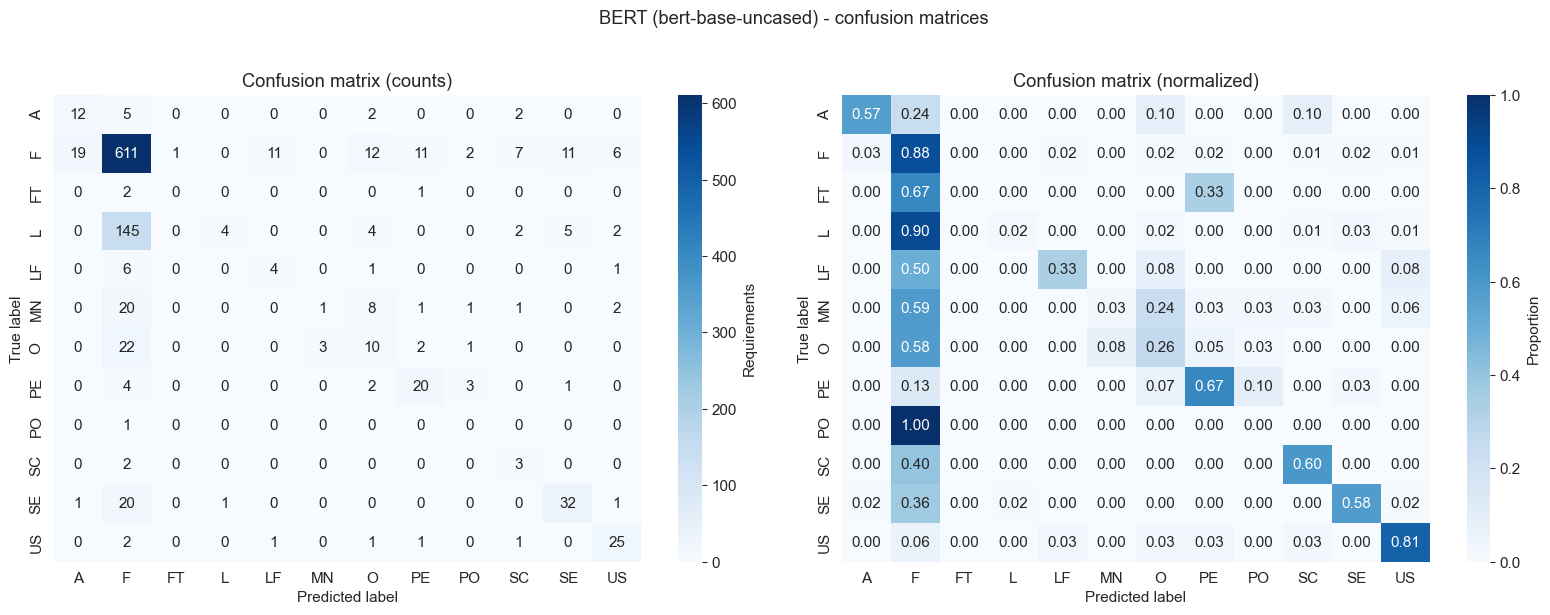

In [8]:
display_labels = sorted(df["class"].unique())
cm = confusion_matrix(y_test, y_pred, labels=display_labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=display_labels, yticklabels=display_labels,
            ax=axes[0], cbar_kws={"label": "Requirements"})
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion matrix (counts)")

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=display_labels, yticklabels=display_labels,
            ax=axes[1], cbar_kws={"label": "Proportion"}, vmin=0, vmax=1)
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Confusion matrix (normalized)")

plt.suptitle("BERT (bert-base-uncased) - confusion matrices", y=1.02)
plt.tight_layout()
save_fig("fig_bert_01_confusion_matrix")
plt.show()

## 9. F1 per class

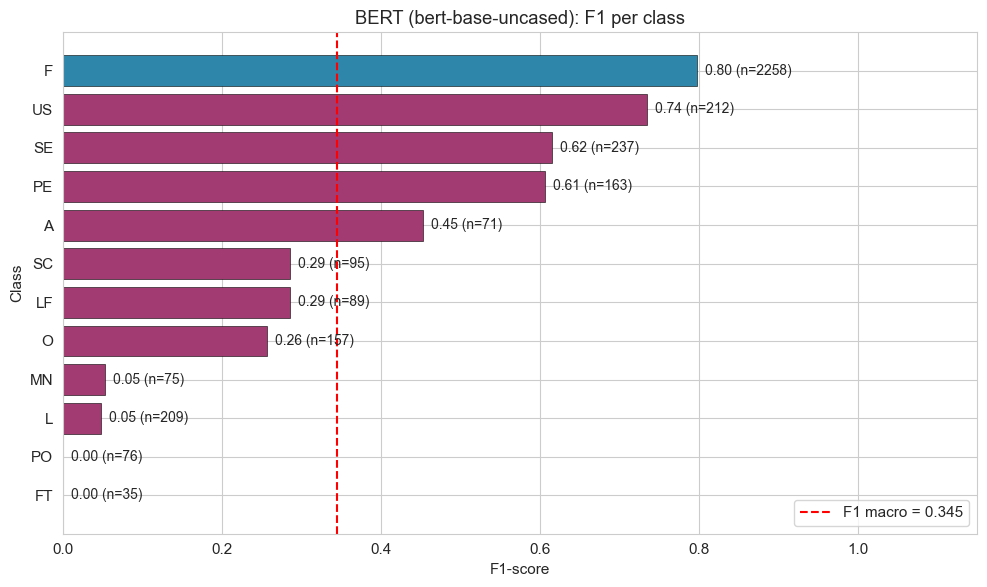

In [9]:
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
per_class = {cls: report[cls]["f1-score"] for cls in display_labels}
per_class_df = pd.Series(per_class).sort_values(ascending=True)

class_sizes = df["class"].value_counts()
sizes_sorted = class_sizes.loc[per_class_df.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#A23B72' if c != 'F' else '#2E86AB' for c in per_class_df.index]
bars = ax.barh(per_class_df.index, per_class_df.values, color=colors,
                edgecolor='black', linewidth=0.4)

for bar, cls, f1, size in zip(bars, per_class_df.index, per_class_df.values, sizes_sorted):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{f1:.2f} (n={size})", va='center', fontsize=10)

ax.axvline(f1_macro, color='red', linestyle='--', linewidth=1.5,
            label=f'F1 macro = {f1_macro:.3f}')
ax.set_xlabel("F1-score")
ax.set_ylabel("Class")
ax.set_title("BERT (bert-base-uncased): F1 per class")
ax.set_xlim(0, 1.15)
ax.legend(loc='lower right')

plt.tight_layout()
save_fig("fig_bert_02_f1_per_class")
plt.show()

## 10. Error analysis

In [10]:
mistakes = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "predicted": y_pred
})
mistakes_wrong = mistakes[mistakes["real"] != mistakes["predicted"]].copy()

print(f"Errors on test set: {len(mistakes_wrong)} / {len(X_test)} ({len(mistakes_wrong)/len(X_test)*100:.1f}%)")
print()

print("Top 10 confusions (real -> predicted):")
confusion_pairs = mistakes_wrong.groupby(["real", "predicted"]).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

print("\nError examples (first 5):")
for _, row in mistakes_wrong.head(5).iterrows():
    print(f"\n  Real: {row['real']} | Predicted: {row['predicted']}")
    print(f"  Text: {row['text'][:200]}")

Errors on test set: 361 / 1083 (33.3%)

Top 10 confusions (real -> predicted):
real  predicted
L     F            145
O     F             22
SE    F             20
MN    F             20
F     A             19
      O             12
      LF            11
      PE            11
      SE            11
MN    O              8
dtype: int64

Error examples (first 5):

  Real: F | Predicted: LF
  Text: The system shall offer a display of all the Events in the exercise.

  Real: LF | Predicted: F
  Text: The application shall match the color of the schema set forth by Department of Homeland Security

  Real: F | Predicted: SC
  Text: The ratings shall be from a scale of 1-10

  Real: US | Predicted: PE
  Text: The product shall increase productivity of Collision Estimators. 80% of the Collision Estimators shall agree their productivity has increase within 1 month of using the product.

  Real: US | Predicted: F
  Text: The product shall be easy to use by Adjusters and Collision Estimators. 95

## 11. Save models and metrics

In [19]:
multi_dir = MODELS_DIR / "bert_multiclass"
binary_dir = MODELS_DIR / "bert_binary"

trainer_multi.save_model(str(multi_dir))
tokenizer.save_pretrained(str(multi_dir))

trainer_bin.save_model(str(binary_dir))
tokenizer.save_pretrained(str(binary_dir))

shutil.rmtree(tmp_multi, ignore_errors=True)
shutil.rmtree(tmp_bin, ignore_errors=True)

print(f"Multi-class model saved: {multi_dir}")
print(f"Binary model saved:      {binary_dir}")

metrics = {
    "multiclass": {
        "model": "bert-base-uncased",
        "n_classes": int(num_classes),
        "n_train": int(len(X_train)),
        "n_val": int(len(X_val)),
        "n_test": int(len(X_test)),
        "seed": int(RANDOM_STATE),
        "test_f1_macro": float(f1_macro),
        "test_f1_weighted": float(f1_weighted),
        "test_accuracy": float(acc),
        "test_per_class_f1": {cls: float(per_class[cls]) for cls in per_class},
    },
    "binary": {
        "model": "bert-base-uncased",
        "n_classes": 2,
        "seed": int(RANDOM_STATE),
        "test_f1_macro": float(f1_macro_bin),
        "test_f1_weighted": float(f1_weighted_bin),
        "test_accuracy": float(acc_bin),
    },
}

metrics_path = MODELS_DIR / "bert_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved: {metrics_path}")
print()
print("Final scores:")
print(f"  Multi-class F1 macro: {f1_macro:.4f}")
print(f"  Binary F1 macro:      {f1_macro_bin:.4f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Multi-class model saved: /Users/luciano/Developer/requirements-analyzer/models/bert_multiclass
Binary model saved:      /Users/luciano/Developer/requirements-analyzer/models/bert_binary
Metrics saved: /Users/luciano/Developer/requirements-analyzer/models/bert_metrics.json

Final scores:
  Multi-class F1 macro: 0.3447
  Binary F1 macro:      0.7103
